In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# 1. 단순 상관계수 (이진변수 간 Pearson 상관계수 = phi coefficient와 동일)
corr = df[['AnyAccepted', 'Response']].corr().iloc[0, 1]
print(f'[1] Pearson 상관계수: {corr:.4f}')
print()

# 2. 분할표(contingency table) 확인
ct = pd.crosstab(df['AnyAccepted'], df['Response'], margins=True)
ct.index = ['AnyAccepted=0', 'AnyAccepted=1', '합계']
ct.columns = ['Response=0', 'Response=1', '합계']
print('[2] 분할표 (교차표)')
print(ct)
print()

# 캠페인 반응률 계산
rate_0 = ct_raw.loc[0, 1] / ct_raw.loc[0].sum() * 100
rate_1 = ct_raw.loc[1, 1] / ct_raw.loc[1].sum() * 100

print('[2-1] 그룹별 캠페인 반응률')
print(f'AnyAccepted=0 그룹 반응률: {rate_0:.2f}%  ({ct_raw.loc[0,1]}명 / {ct_raw.loc[0].sum()}명)')
print(f'AnyAccepted=1 그룹 반응률: {rate_1:.2f}%  ({ct_raw.loc[1,1]}명 / {ct_raw.loc[1].sum()}명)')
print(f'반응률 배율: {rate_1/rate_0:.2f}배')
print()

# 3. 카이제곱 검정
ct_raw = pd.crosstab(df['AnyAccepted'], df['Response'])
chi2, p_value, dof, expected = chi2_contingency(ct_raw)

print('[3] 카이제곱 독립성 검정')
print(f'chi2 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.8f}')
print(f'자유도: {dof}')
print(f'-> {"유의함 (연관 있음)" if p_value < 0.05 else "유의하지 않음 (독립적)"}  (유의수준 0.05 기준)')
print()

# 4. 오즈비 계산
a = ct_raw.loc[1, 1]  # AnyAccepted=1, Response=1
b = ct_raw.loc[1, 0]  # AnyAccepted=1, Response=0
c = ct_raw.loc[0, 1]  # AnyAccepted=0, Response=1
d = ct_raw.loc[0, 0]  # AnyAccepted=0, Response=0

odds_ratio = (a * d) / (b * c)
print('[4] 오즈비 (Odds Ratio)')
print(f'AnyAccepted=1 그룹 오즈: {a/b:.4f}')
print(f'AnyAccepted=0 그룹 오즈: {c/d:.4f}')
print(f'오즈비: {odds_ratio:.4f}')
print(f'-> AnyAccepted=1인 고객은 0인 고객보다 Response=1일 오즈가 {odds_ratio:.2f}배 높음')
print()

# 5. 로지스틱 회귀 (계수, p-value, 신뢰구간까지 한 번에)
model = smf.logit('Response ~ AnyAccepted', data=df).fit()
print()
print('[5] 로지스틱 회귀 결과')
print(model.summary())

print()
or_from_model = np.exp(model.params['AnyAccepted'])
ci = np.exp(model.conf_int().loc['AnyAccepted'])
print(f'오즈비 (로지스틱 회귀 기준): {or_from_model:.4f}')
print(f'95% 신뢰구간: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'p-value: {model.pvalues["AnyAccepted"]:.6f}')

# 6. 그룹별 Response 비율 요약
print()
summary = df.groupby('AnyAccepted')['Response'].agg(['mean', 'count'])
summary.columns = ['Response 비율', '표본수']
summary['Response 비율'] = (summary['Response 비율'] * 100).round(2)
print('[6] 그룹별 Response 비율 요약')
print(summary)

[1] Pearson 상관계수: 0.3691

[2] 분할표 (교차표)
               Response=0  Response=1    합계
AnyAccepted=0        1475         138  1613
AnyAccepted=1         248         175   423
합계                   1723         313  2036

[2-1] 그룹별 캠페인 반응률
AnyAccepted=0 그룹 반응률: 8.56%  (138명 / 1613명)
AnyAccepted=1 그룹 반응률: 41.37%  (175명 / 423명)
반응률 배율: 4.84배

[3] 카이제곱 독립성 검정
chi2 통계량: 274.8700
p-value: 0.00000000
자유도: 1
-> 유의함 (연관 있음)  (유의수준 0.05 기준)

[4] 오즈비 (Odds Ratio)
AnyAccepted=1 그룹 오즈: 0.7056
AnyAccepted=0 그룹 오즈: 0.0936
오즈비: 7.5422
-> AnyAccepted=1인 고객은 0인 고객보다 Response=1일 오즈가 7.54배 높음

Optimization terminated successfully.
         Current function value: 0.372337
         Iterations 6

[5] 로지스틱 회귀 결과
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2034
Method:                           MLE   Df Model:                   

과거 캠페인 수락 경험은 이번 캠페인 반응 여부와 강하고 통계적으로 유의한 관계가 있다. 한 번이라도 캠페인에 반응했던 고객은, 그렇지 않은 고객보다 이번에도 반응할 가능성이 훨씬 높다 (반응률 기준 4.8배, 오즈 기준 7.5배). 이 결과는 여러 통계적 방법(카이제곱, 오즈비, 로지스틱 회귀)에서 일관되게 확인되어 신뢰도가 높다.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv('marketing_clean_final.csv')

# Recency를 추가한 통제 모델
model4 = smf.logit(
    'Response ~ AnyAccepted + Income + MntWines + Age + Children + C(Education) + C(Marital_Status) + Recency',
    data=df
).fit()

print(model4.summary())

# 오즈비 및 신뢰구간 정리
result4 = pd.DataFrame({
    'coef': model4.params,
    'p_value': model4.pvalues,
    'odds_ratio': np.exp(model4.params),
    'CI_lower': np.exp(model4.conf_int()[0]),
    'CI_upper': np.exp(model4.conf_int()[1])
}).round(4)

print(result4)

# Recency 추가 전(model3) vs 추가 후(model4) 비교
model3 = smf.logit(
    'Response ~ AnyAccepted + Income + MntWines + Age + Children + C(Education) + C(Marital_Status)',
    data=df
).fit(disp=0)

print('=== Recency 추가 전후 비교 ===')
print(f"model3 (Recency 없음) - AnyAccepted 오즈비: {np.exp(model3.params['AnyAccepted']):.4f}, Pseudo R²: {model3.prsquared:.4f}")
print(f"model4 (Recency 포함) - AnyAccepted 오즈비: {np.exp(model4.params['AnyAccepted']):.4f}, Pseudo R²: {model4.prsquared:.4f}")
print(f"Recency 오즈비: {np.exp(model4.params['Recency']):.4f}, p-value: {model4.pvalues['Recency']:.6f}")

Optimization terminated successfully.
         Current function value: 0.324069
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2022
Method:                           MLE   Df Model:                           13
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                  0.2448
Time:                        16:23:10   Log-Likelihood:                -659.80
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 2.957e-83
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -1.2924      0.813     -1.590      0.

소득, 지출, 나이, 자녀 수, 학력, 결혼상태, 최근 구매 시점을 모두 통제해도 **과거 캠페인 참여 이력(오즈비 6.76)**과 **최근 구매일(Recency, 오즈비 0.975)**은 이번 캠페인 반응을 예측하는 가장 강력하고 독립적인 변수이며, 여기에 자녀 수가 적을수록, PhD 학력일수록, 미혼/이혼 상태일수록 반응 가능성이 유의하게 높아진다.

사용할 특징: ['Income', 'Age', 'Children', 'Education_encoded', 'TotalAmount', 'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Together', 'Marital_Widow']


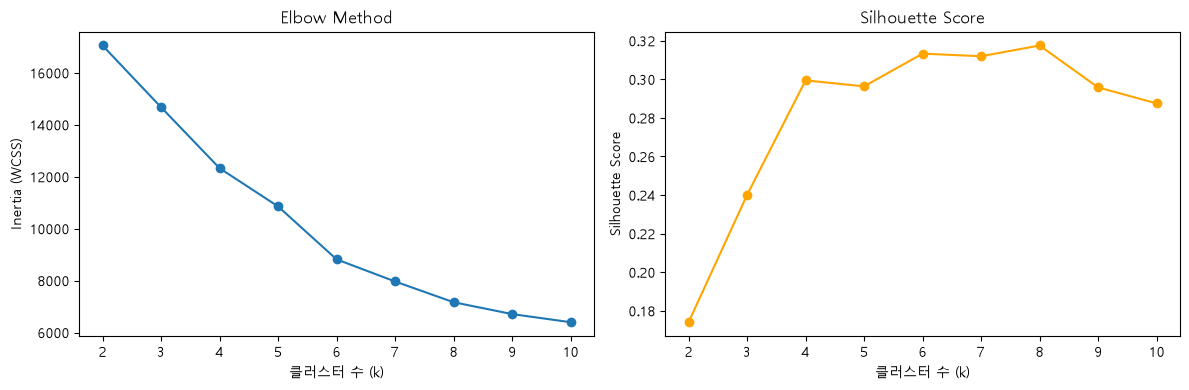

k=2: silhouette=0.1741
k=3: silhouette=0.2401
k=4: silhouette=0.2995
k=5: silhouette=0.2964
k=6: silhouette=0.3133
k=7: silhouette=0.3120
k=8: silhouette=0.3175
k=9: silhouette=0.2958
k=10: silhouette=0.2875


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

# Education은 순서형 유지
education_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(education_order)

# 지출 합계
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalAmount'] = df[mnt_cols].sum(axis=1)

# Marital_Status는 One-Hot 인코딩으로 변경
marital_dummies = pd.get_dummies(df['Marital_Status'], prefix='Marital').astype(int)
df = pd.concat([df, marital_dummies], axis=1)

# 클러스터링 특징 구성
base_cols = ['Income', 'Age', 'Children', 'Education_encoded', 'TotalAmount']
feature_cols = base_cols + list(marital_dummies.columns)
X = df[feature_cols].copy()

print('사용할 특징:', feature_cols)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + Silhouette
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=777, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

K=3 실루엣 스코어: 0.2052
Cluster
0    678
1    841
2    517
Name: count, dtype: int64
         count  Income_avg  Age_avg  Children_avg  Education_avg  Marital_avg  \
Cluster                                                                         
0          678    74599.80    46.86          0.37           1.59         2.56   
1          841    36263.89    41.22          1.15           1.14         2.64   
2          517    48112.70    49.21          1.40           2.62         2.58   

         TotalAmount_avg  AnyAccepted_rate  Response_rate  
Cluster                                                    
0                1309.00              0.39           0.24  
1                 190.74              0.11           0.09  
2                 358.83              0.13           0.13  


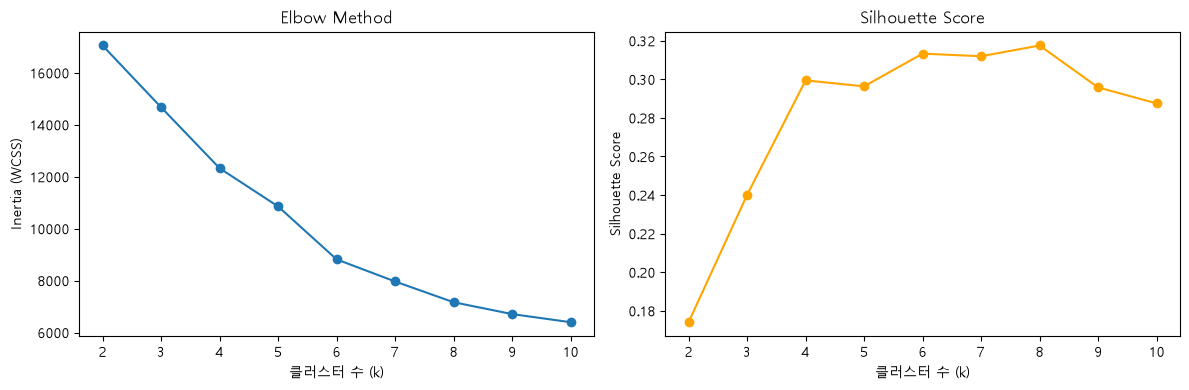

k=2: silhouette=0.1741
k=3: silhouette=0.2401
k=4: silhouette=0.2995
k=5: silhouette=0.2964
k=6: silhouette=0.3133
k=7: silhouette=0.3120
k=8: silhouette=0.3175
k=9: silhouette=0.2958
k=10: silhouette=0.2875


In [19]:
kmeans = KMeans(n_clusters=4, random_state=777, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f'K=4 실루엣 스코어: {sil_score:.4f}')
print(df['Cluster'].value_counts().sort_index())

cluster_profile = df.groupby('Cluster').agg(
    count=('ID', 'count'),
    Income_avg=('Income', 'mean'),
    Age_avg=('Age', 'mean'),
    Children_avg=('Children', 'mean'),
    Education_avg=('Education_encoded', 'mean'),
    TotalAmount_avg=('TotalAmount', 'mean'),
    AnyAccepted_rate=('AnyAccepted', 'mean'),
    Response_rate=('Response', 'mean')
).round(2)

print(cluster_profile)

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    print(f'--- Cluster {c} (n={len(sub)}) ---')
    print('Education 분포:', sub['Education'].value_counts(normalize=True).round(2).to_dict())
    print('Marital_Status 분포:', sub['Marital_Status'].value_counts(normalize=True).round(2).to_dict())
    print()

K=4 실루엣 스코어: 0.2995
Cluster
0    788
1    516
2    520
3    212
Name: count, dtype: int64
         count  Income_avg  Age_avg  Children_avg  Education_avg  \
Cluster                                                            
0          788    51906.06    44.52          0.97           1.68   
1          516    52175.30    45.72          0.98           1.67   
2          520    51701.37    44.37          0.87           1.63   
3          212    53027.02    47.79          1.02           1.67   

         TotalAmount_avg  AnyAccepted_rate  Response_rate  
Cluster                                                    
0                 594.17              0.21           0.12  
1                 604.16              0.20           0.11  
2                 623.12              0.22           0.24  
3                 610.66              0.19           0.20  
--- Cluster 0 (n=788) ---
Education 분포: {'Graduation': 0.5, 'Master': 0.25, 'PhD': 0.23, 'Basic': 0.02}
Marital_Status 분포: {'Married': 1.0}



PC1+PC2 설명분산: 36.5%


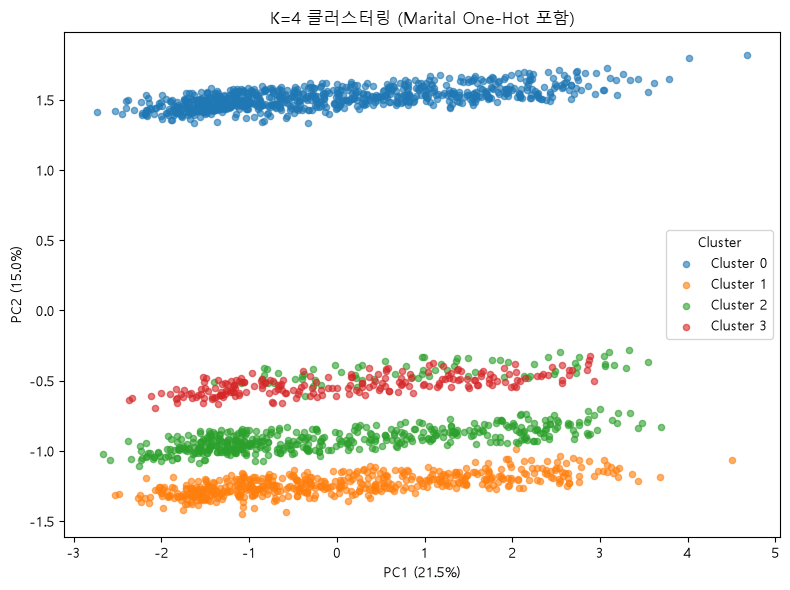

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f'PC1+PC2 설명분산: {sum(pca.explained_variance_ratio_)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors[c], label=f'Cluster {c}', alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K=4 클러스터링 (Marital One-Hot 포함)')
ax.legend(title='Cluster')

plt.tight_layout()
plt.show()

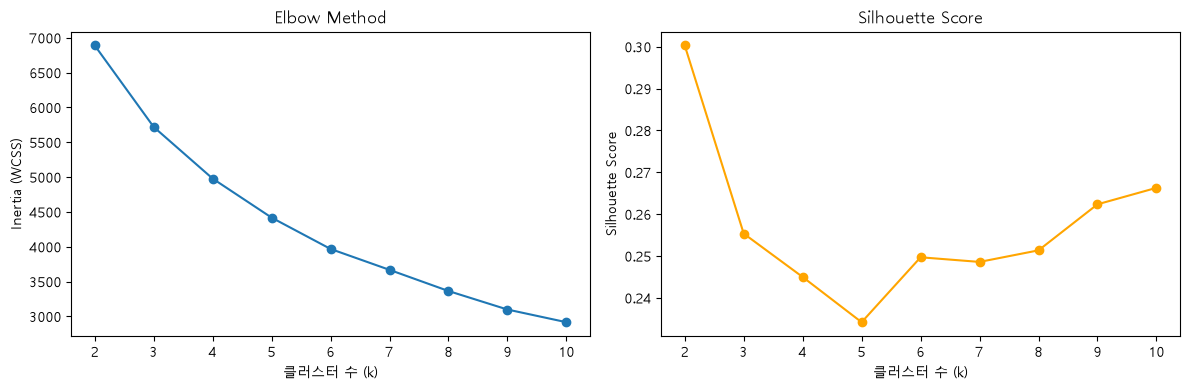

k=2: silhouette=0.3003
k=3: silhouette=0.2554
k=4: silhouette=0.2450
k=5: silhouette=0.2342
k=6: silhouette=0.2497
k=7: silhouette=0.2486
k=8: silhouette=0.2514
k=9: silhouette=0.2624
k=10: silhouette=0.2663


In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_clean_final.csv')

education_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_encoded'] = df['Education'].map(education_order)

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalAmount'] = df[mnt_cols].sum(axis=1)

# Marital_Status는 클러스터링에서 제외 (프로파일링에는 나중에 활용 가능)
feature_cols = ['Income', 'Age', 'Children', 'Education_encoded', 'TotalAmount']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=777, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

In [22]:
kmeans = KMeans(n_clusters=3, random_state=777, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f'K=3 실루엣 스코어: {sil_score:.4f}')
print(df['Cluster'].value_counts().sort_index())

cluster_profile = df.groupby('Cluster').agg(
    count=('ID', 'count'),
    Income_avg=('Income', 'mean'),
    Age_avg=('Age', 'mean'),
    Children_avg=('Children', 'mean'),
    Education_avg=('Education_encoded', 'mean'),
    TotalAmount_avg=('TotalAmount', 'mean'),
    AnyAccepted_rate=('AnyAccepted', 'mean'),
    Response_rate=('Response', 'mean')
).round(2)

print(cluster_profile)

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    print(f'--- Cluster {c} (n={len(sub)}) ---')
    print('Education 분포:', sub['Education'].value_counts(normalize=True).round(2).to_dict())
    print('Marital_Status 분포:', sub['Marital_Status'].value_counts(normalize=True).round(2).to_dict())
    print()

K=3 실루엣 스코어: 0.2554
Cluster
0    677
1    845
2    514
Name: count, dtype: int64
         count  Income_avg  Age_avg  Children_avg  Education_avg  \
Cluster                                                            
0          677    74618.90    46.86          0.37           1.59   
1          845    36278.80    41.26          1.15           1.14   
2          514    48206.79    49.20          1.40           2.62   

         TotalAmount_avg  AnyAccepted_rate  Response_rate  
Cluster                                                    
0                1309.85              0.39           0.25  
1                 190.44              0.11           0.10  
2                 361.35              0.14           0.13  
--- Cluster 0 (n=677) ---
Education 분포: {'Graduation': 0.58, 'Master': 0.24, 'PhD': 0.18}
Marital_Status 분포: {'Married': 0.38, 'Together': 0.25, 'Single': 0.22, 'Divorced': 0.11, 'Widow': 0.05}

--- Cluster 1 (n=845) ---
Education 분포: {'Graduation': 0.74, 'Master': 0.2, 'Basic'

PC1+PC2 설명분산: 66.7%


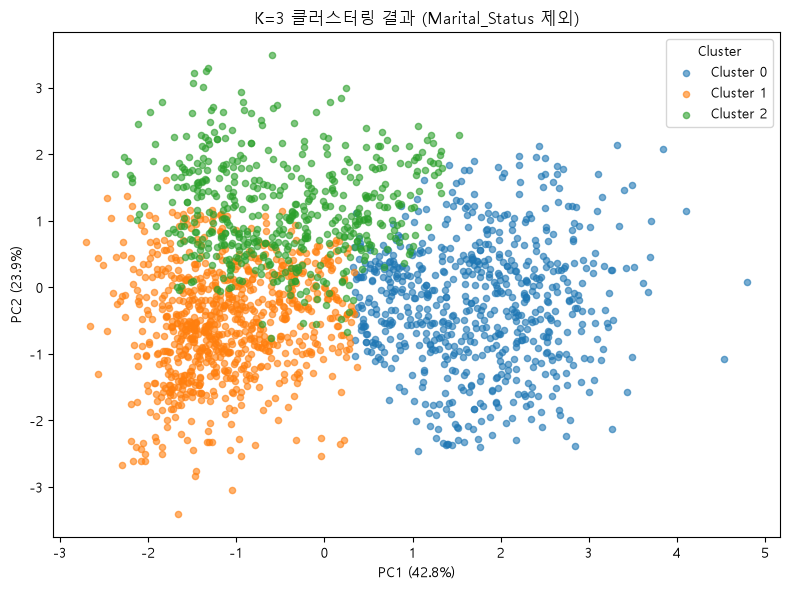

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f'PC1+PC2 설명분산: {sum(pca.explained_variance_ratio_)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors[c], label=f'Cluster {c}', alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K=3 클러스터링 결과 (Marital_Status 제외)')
ax.legend(title='Cluster')

plt.tight_layout()
plt.show()